<a href="https://colab.research.google.com/github/donkey-king-kong/CSCI-4907---NLU/blob/main/(GWU)_CSCI_4907_NLU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Machine Learning
Machine learning is a branch of artificial intelligence that focuses on developing algorithms and statistical models that allow us to learn from our data and make any predicitons or decisions without explicitly programming it. 

Machine learning can identify patterns across large datasets that is impossible for the human to do so efficiently. The machine's performance can also be improved over time as they are more exposed to more data or by fine-tuning certain parameters.

### **Train-Test Split**

We split the data into train and test with the proportion 75:25

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score ,classification_report,confusion_matrix

In [17]:
x = df['tweet_clean']
y,class_names = pd.factorize(df['cyberbullying_type'],sort=True)

X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=5)

x_train = []
for x in X_train:
    x_train.append(str(x))

x_test = []
for x in X_test:
    x_test.append(str(x))

### Classifier Report Function

In [18]:
def Classifier(model):
    # Initialize a TfidfVectorizer
    vectorizer = TfidfVectorizer()

    # Fit the vectorizer on the cleaned tweet data
    vectorizer.fit(df['tweet_clean'])

    # Transform training and testing data to TF-IDF vectors
    x_train_vecs = vectorizer.transform(x_train)
    x_test_vecs = vectorizer.transform(x_test)

    # Train the model on the TF-IDF vectors of the training data
    model.fit(x_train_vecs, y_train)

    # Predict the labels for the testing data
    y_pred = model.predict(x_test_vecs)

    # Print accuracy score and classification report
    print('Accuracy: {:.3f}'.format(accuracy_score(y_test, y_pred)))
    print()
    print("Classification Report: \n", classification_report(y_test, y_pred))

    # Generate confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)

    # Plot confusion matrix as a heatmap
    sb.heatmap(conf_matrix, annot=True, fmt='d', cmap=None, xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

**ROC Curve** 
 
The ROC curve illustrates the balance between true positive rate (TPR) and false positive rate (FPR) across different thresholds. A model excels when its curve hugs the top-left corner, indicating high TPR and low FPR. Conversely, a curve closer to the diagonal line signifies poor ability to discriminate, no better than random chance.

In [20]:
#ROC Curve

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [21]:
#Define Class Labels
class_labels = [ 'age', 'gender', 'ethnicity', 'not_cyberbullying','other_cyberbullying', 'religion']

def plot_roc_curves(model, x_test, y_test):
    # Get the number of classes
    num_classes = len(np.unique(y_test))

    # Initialize the figure
    plt.figure(figsize=(8, 6))

    # Plot ROC curve for each class
    for i in range(num_classes):
        # Treat the current class as positive and the rest as negative
        y_true_class = np.where(y_test == i, 1, 0)

        # Predict probabilities for the current class
        y_probs_class = model.predict_proba(x_test)

        # Calculate false positive rate and true positive rate
        fpr, tpr, _ = roc_curve(y_true_class, y_probs_class[:, i])

        # Calculate area under the curve
        roc_auc = auc(fpr, tpr)

        # Plot ROC curve for the current class
        plt.plot(fpr, tpr, lw=2, label='ROC curve for {} (area = {:.2f})'.format(class_labels[i], roc_auc))

    # Plot random guess line
    plt.plot([0, 1], [0, 1], color='red', linestyle='--')

    # Set plot labels and title
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curves')
    plt.legend(loc='lower right')
    plt.show()

**Learning Curve**

A learning curve is a plot that shows how a model's performance, often measured by accuracy, changes as the size of the training dataset increases. It helps assess if the model benefits from more data and can reveal issues like overfitting or underfitting. Cross-validation scores are often included for a more reliable estimate of performance.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

In [24]:
def plot_learning_curve_multi_class(model, x_train, y_train, class_labels, train_sizes=np.linspace(0.1, 1.0, 5)):
    train_sizes, train_scores, test_scores = learning_curve(
        model, x_train, y_train, train_sizes=train_sizes, cv=5, scoring='accuracy')

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")

    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.title("Learning Curve")
    plt.legend(loc="best")
    plt.grid()
    plt.show()


### **Random Forest**

Random Forest Classifier is an ensemble learning technique for classification tasks, which builds multiple decision trees and outputs the mode of the classes predicted by individual trees. It's effective, versatile, and resistant to overfitting. The model shows good results in prediction of cyberbullying type in our tweets.

Accuracy: 0.812

Classification Report: 
               precision    recall  f1-score   support

           0       0.97      0.98      0.98      1952
           1       0.98      0.98      0.98      1995
           2       0.90      0.83      0.86      1952
           3       0.58      0.46      0.51      2040
           4       0.53      0.68      0.60      2006
           5       0.95      0.96      0.95      1978

    accuracy                           0.81     11923
   macro avg       0.82      0.81      0.81     11923
weighted avg       0.82      0.81      0.81     11923



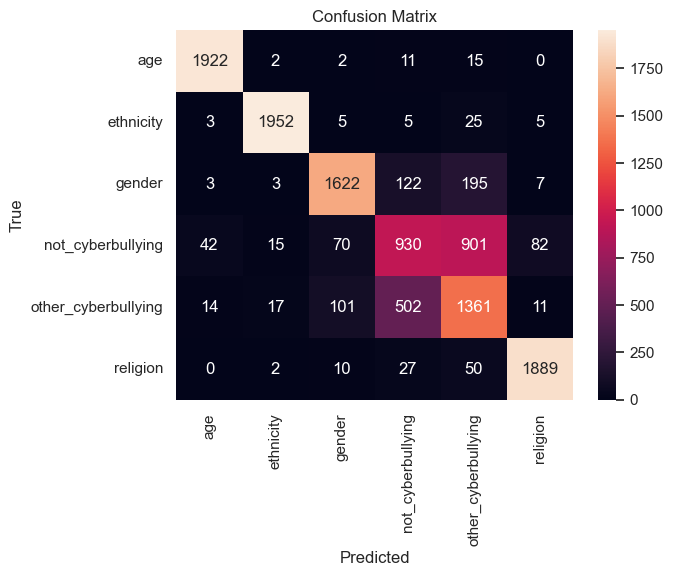

In [26]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest Classifier model pass it to the Classifier function
model=RandomForestClassifier()
Classifier(model)

**ROC Curve**

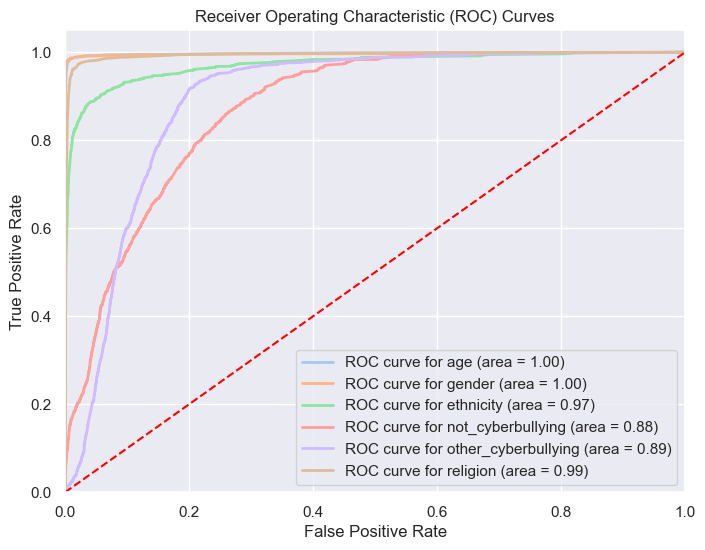

In [27]:
plot_roc_curves(model, x_test_vecs, y_test)

**Learning Curve**

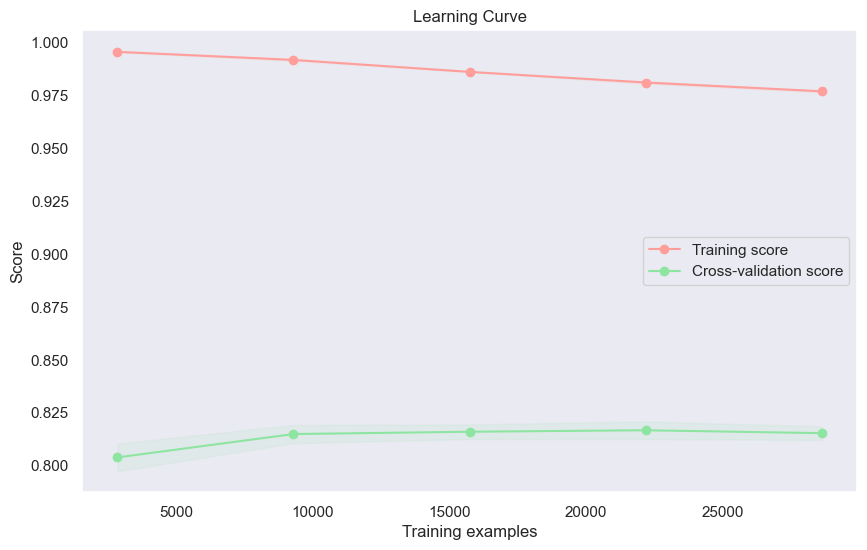

In [28]:
plot_learning_curve_multi_class(model, x_train_vecs, y_train, class_labels)

*ADVANTAGES*

- Often produces highly accurate predictions, even without extensive hyperparameter tuning.

- By aggregating predictions from multiple decision trees, Random Forest is less prone to overfitting compared to individual decision trees.

- Random Forest can efficiently handle large datasets with many features and instances, making it suitable for complex problems.

- Can handle missing values in the dataset without the need for imputation, reducing preprocessing requirements.

*DISADVANTAGES*

- The ensemble nature of it makes it less interpretable compared to simpler models, as it's challenging to trace predictions back to individual trees.

- Training this model can be computationally expensive, especially for large datasets with numerous trees and deep trees.

- Random Forest tends to be biased towards the majority class in imbalanced datasets, potentially leading to suboptimal performance for minority classes.